Dataset Shape: (150, 4)
Target Shape: (150,)
Training Set Shape: (120, 4)
Testing Set Shape: (30, 4)

Logistic Regression Accuracy:
93.33%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


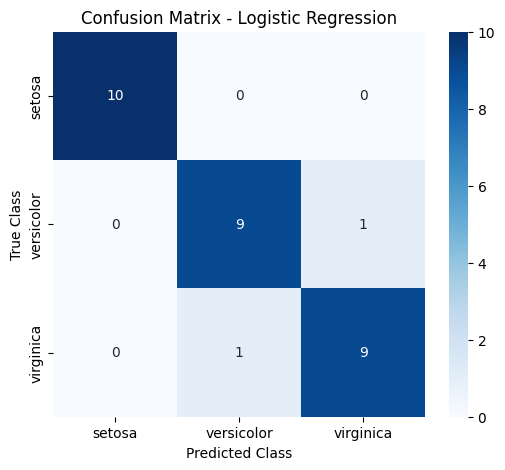


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Weighted Precision: 0.9333
Weighted Recall: 0.9333
Weighted F1-Score: 0.9333


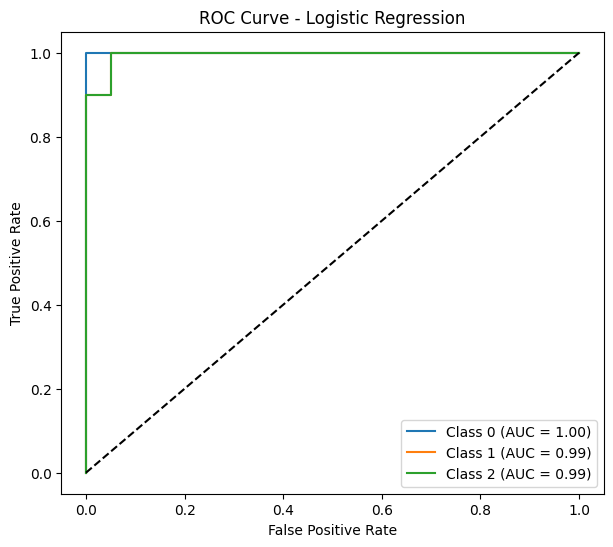


5-Fold Cross-Validation Accuracy:
Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000

Mean Accuracy: 96.00%
Standard Deviation: 3.89%

Final Performance Summary:
          Metric    Score
        Accuracy 0.933333
       Precision 0.933333
          Recall 0.933333
        F1-Score 0.933333
Mean CV Accuracy 0.960000

Task 3 Completed Successfully.


In [1]:
# Experiment 03 - Task 03
# Model Performance Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score
)
from sklearn.metrics import precision_score, recall_score, f1_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)

# Prediction probabilities for ROC
y_score = lr_model.predict_proba(X_test)

# Accuracy
accuracy = accuracy_score(y_test, lr_preds)

print("\nLogistic Regression Accuracy:")
print(f"{accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, lr_preds)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# Classification Report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        lr_preds,
        target_names=iris.target_names
    )
)

# Precision
precision = precision_score(
    y_test,
    lr_preds,
    average="weighted"
)

# Recall
recall = recall_score(
    y_test,
    lr_preds,
    average="weighted"
)

# F1-score
f1 = f1_score(
    y_test,
    lr_preds,
    average="weighted"
)

print("Weighted Precision:", round(precision, 4))
print("Weighted Recall:", round(recall, 4))
print("Weighted F1-Score:", round(f1, 4))

# ROC Analysis
y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

plt.figure(figsize=(7, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {i} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

# 5-Fold Cross Validation
cv_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

cv_scores = cross_val_score(
    cv_model,
    X_scaled,
    y,
    cv=5,
    scoring="accuracy"
)

print("\n5-Fold Cross-Validation Accuracy:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

mean_accuracy = np.mean(cv_scores)
std_accuracy = np.std(cv_scores)

print(
    f"\nMean Accuracy: {mean_accuracy * 100:.2f}%"
)

print(
    f"Standard Deviation: {std_accuracy * 100:.2f}%"
)

# Final summary
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Mean CV Accuracy"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        mean_accuracy
    ]
})

print("\nFinal Performance Summary:")
print(results.to_string(index=False))

print("\nTask 3 Completed Successfully.")

## Conclusion

The Logistic Regression model was evaluated using a confusion matrix, precision, recall, F1-score, ROC analysis, and 5-fold cross-validation. These evaluation methods provide a comprehensive assessment of classification performance and model reliability.